In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Dataset
from torch.utils.data.dataloader import default_collate
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import pickle
import gc
import os
from tqdm import tqdm

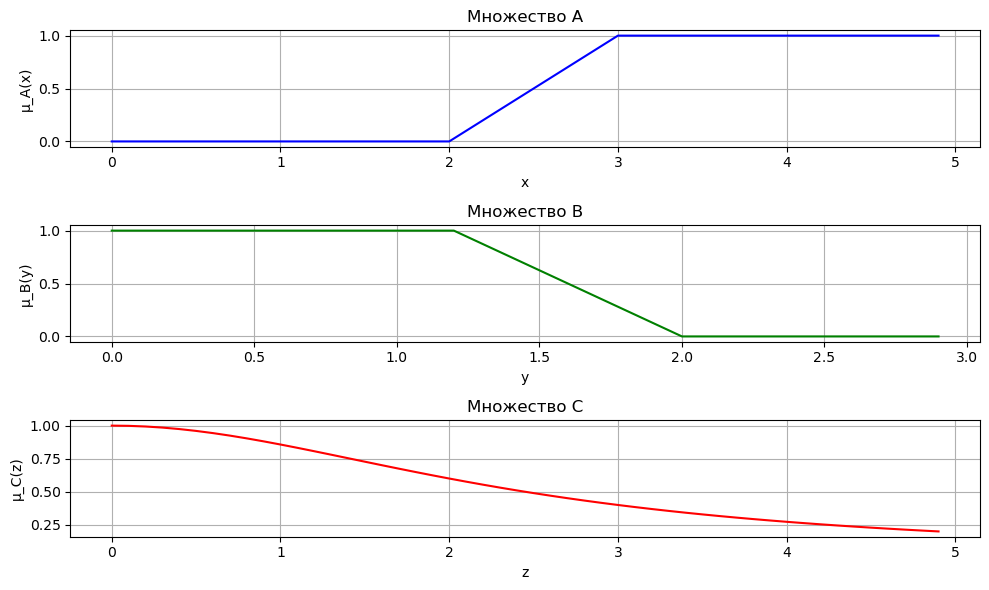

(      x  μ_A(x)
 0   0.0     0.0
 1   0.1     0.0
 2   0.2     0.0
 3   0.3     0.0
 4   0.4     0.0
 5   0.5     0.0
 6   0.6     0.0
 7   0.7     0.0
 8   0.8     0.0
 9   0.9     0.0
 10  1.0     0.0
 11  1.1     0.0
 12  1.2     0.0
 13  1.3     0.0
 14  1.4     0.0
 15  1.5     0.0
 16  1.6     0.0
 17  1.7     0.0
 18  1.8     0.0
 19  1.9     0.0
 20  2.0     0.0
 21  2.1     0.1
 22  2.2     0.2
 23  2.3     0.3
 24  2.4     0.4
 25  2.5     0.5
 26  2.6     0.6
 27  2.7     0.7
 28  2.8     0.8
 29  2.9     0.9
 30  3.0     1.0
 31  3.1     1.0
 32  3.2     1.0
 33  3.3     1.0
 34  3.4     1.0
 35  3.5     1.0
 36  3.6     1.0
 37  3.7     1.0
 38  3.8     1.0
 39  3.9     1.0
 40  4.0     1.0
 41  4.1     1.0
 42  4.2     1.0
 43  4.3     1.0
 44  4.4     1.0
 45  4.5     1.0
 46  4.6     1.0
 47  4.7     1.0
 48  4.8     1.0
 49  4.9     1.0,
       y  μ_B(y)
 0   0.0   1.000
 1   0.1   1.000
 2   0.2   1.000
 3   0.3   1.000
 4   0.4   1.000
 5   0.5   1.000
 6   0.6   1.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Определение функции принадлежности для множества A
def mu_A(x, n=6):
    if 0 <= x <= n/3:
        return 0
    elif n/3 < x <= n/2:
        return x - 2
    else:
        return 1

# Определение функции принадлежности для множества B
def mu_B(y, n=6):
    if 0 <= y <= n/5:
        return 1
    elif n/5 < y <= n/3:
        return 2.5 - 1.25 * y
    else:
        return 0

# Определение функции принадлежности для множества C
def mu_C(z, n=6):
    return 1 / (1 + (1/n) * z**2)

# Табличные данные с шагом 0.1
x_values = np.arange(0, 5, 0.1)
y_values = np.arange(0, 3, 0.1)
z_values = np.arange(0, 5, 0.1)

# Вычисление функций принадлежности для каждого множества
A_values = [mu_A(x) for x in x_values]
B_values = [mu_B(y) for y in y_values]
C_values = [mu_C(z) for z in z_values]

# Построение графиков
plt.figure(figsize=(10, 6))

# График для A
plt.subplot(3, 1, 1)
plt.plot(x_values, A_values, label='A(x) - "Величина x - большая"', color='b')
plt.xlabel('x')
plt.ylabel('μ_A(x)')
plt.title('Множество A')
plt.grid(True)

# График для B
plt.subplot(3, 1, 2)
plt.plot(y_values, B_values, label='B(y) - "Величина y - малая"', color='g')
plt.xlabel('y')
plt.ylabel('μ_B(y)')
plt.title('Множество B')
plt.grid(True)

# График для C
plt.subplot(3, 1, 3)
plt.plot(z_values, C_values, label='C(z) - "Величина z - малая"', color='r')
plt.xlabel('z')
plt.ylabel('μ_C(z)')
plt.title('Множество C')
plt.grid(True)

plt.tight_layout()
plt.show()

# Создание таблицы
df_A = pd.DataFrame({'x': x_values, 'μ_A(x)': A_values})
df_B = pd.DataFrame({'y': y_values, 'μ_B(y)': B_values})
df_C = pd.DataFrame({'z': z_values, 'μ_C(z)': C_values})

df_A, df_B, df_C


In [14]:
for i, j in enumerate(x_values):
    print(i+ 19, j)

19 0.0
20 0.1
21 0.2
22 0.30000000000000004
23 0.4
24 0.5
25 0.6000000000000001
26 0.7000000000000001
27 0.8
28 0.9
29 1.0
30 1.1
31 1.2000000000000002
32 1.3
33 1.4000000000000001
34 1.5
35 1.6
36 1.7000000000000002
37 1.8
38 1.9000000000000001
39 2.0
40 2.1
41 2.2
42 2.3000000000000003
43 2.4000000000000004
44 2.5
45 2.6
46 2.7
47 2.8000000000000003
48 2.9000000000000004
49 3.0
50 3.1
51 3.2
52 3.3000000000000003
53 3.4000000000000004
54 3.5
55 3.6
56 3.7
57 3.8000000000000003
58 3.9000000000000004
59 4.0
60 4.1000000000000005
61 4.2
62 4.3
63 4.4
64 4.5
65 4.6000000000000005
66 4.7
67 4.800000000000001
68 4.9


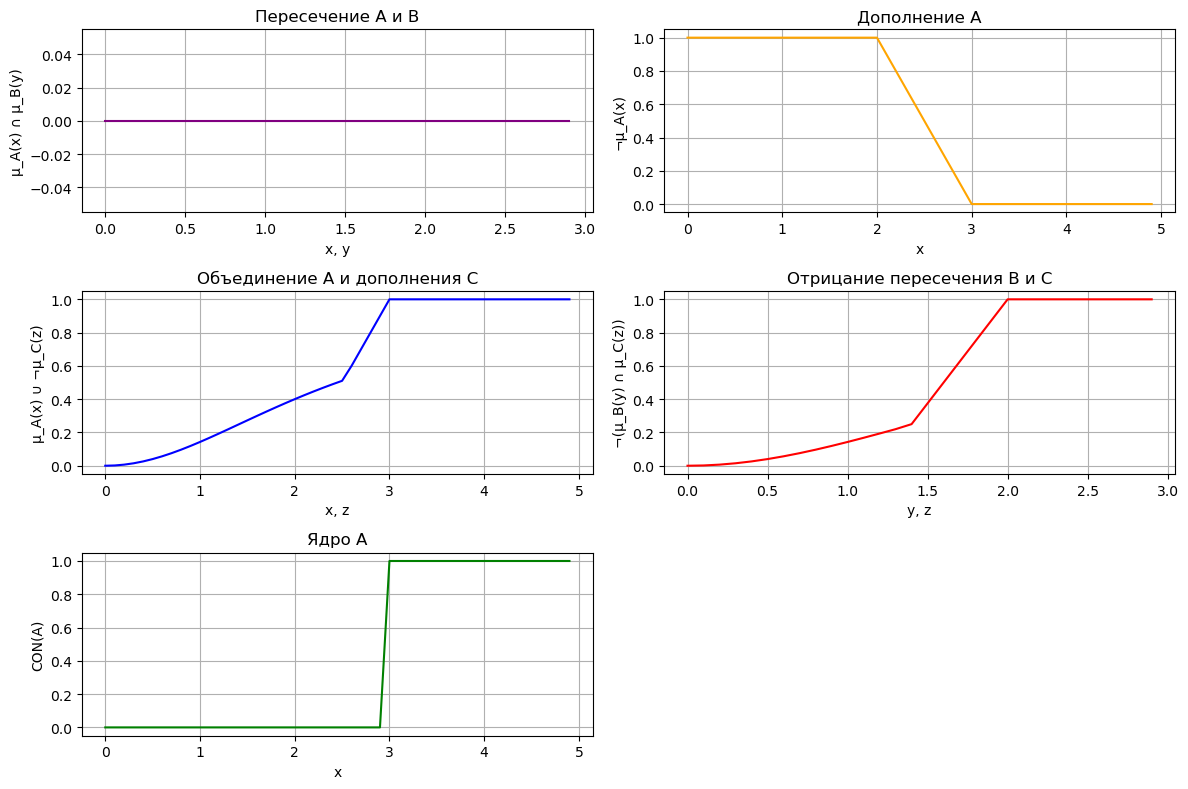

In [2]:
# 2. Величина x большая И величина y малая (пересечение)
intersection_A_B = [min(mu_A(x), mu_B(y)) for x, y in zip(x_values[:min(len(x_values), len(y_values))], y_values)]

# 3. Величина x не является большой (дополнение A)
complement_A = [1 - mu_A(x) for x in x_values]

# 4. Величина x большая ИЛИ величина z не является малой (объединение A и дополнение C)
complement_C = [1 - mu_C(z) for z in z_values]
union_A_complement_C = [max(mu_A(x), complement_C[i]) for i, x in enumerate(x_values[:min(len(x_values), len(z_values))])]

# 5. Не верно, что y и z одновременно являются малыми (НЕ пересечение B и C)
not_intersection_B_C = [1 - min(mu_B(y), mu_C(z)) for y, z in zip(y_values[:min(len(y_values), len(z_values))], z_values)]

# 6. Ядро множества A (CON(A)) - индексы, где принадлежность равна 1
core_A = [1 if mu_A(x) == 1 else 0 for x in x_values]

# Построение графиков
plt.figure(figsize=(12, 8))

# График пересечения A и B
plt.subplot(3, 2, 1)
plt.plot(x_values[:min(len(x_values), len(y_values))], intersection_A_B, label='A ∩ B', color='purple')
plt.xlabel('x, y')
plt.ylabel('μ_A(x) ∩ μ_B(y)')
plt.title('Пересечение A и B')
plt.grid(True)

# График дополнения A
plt.subplot(3, 2, 2)
plt.plot(x_values, complement_A, label='¬A', color='orange')
plt.xlabel('x')
plt.ylabel('¬μ_A(x)')
plt.title('Дополнение A')
plt.grid(True)

# График объединения A и дополнения C
plt.subplot(3, 2, 3)
plt.plot(x_values[:min(len(x_values), len(z_values))], union_A_complement_C, label='A ∪ ¬C', color='blue')
plt.xlabel('x, z')
plt.ylabel('μ_A(x) ∪ ¬μ_C(z)')
plt.title('Объединение A и дополнения C')
plt.grid(True)

# График не пересечения B и C
plt.subplot(3, 2, 4)
plt.plot(y_values[:min(len(y_values), len(z_values))], not_intersection_B_C, label='¬(B ∩ C)', color='red')
plt.xlabel('y, z')
plt.ylabel('¬(μ_B(y) ∩ μ_C(z))')
plt.title('Отрицание пересечения B и C')
plt.grid(True)

# График ядра множества A
plt.subplot(3, 2, 5)
plt.plot(x_values, core_A, label='CON(A)', color='green')
plt.xlabel('x')
plt.ylabel('CON(A)')
plt.title('Ядро A')
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
f = lambda x, y: 0.56*x + 0.44*y

print(f(2200, 1800))
print(f(2200, 180))
print(f(2200, 180))
print(f(2200, 180))